# Transformer Set Autoencoder per Emerging Jets

Questo notebook implementa un **Transformer per set non ordinati di tracce**.

Idea:

- ogni jet e' un insieme di tracce;
- ogni traccia e' un token;
- non usiamo positional encoding sequenziale, perche' l'ordine delle tracce non e' fisico;
- usiamo `track_mask` per ignorare il padding;
- il Transformer Encoder fa self-attention tra tracce;
- il modello produce un embedding globale del jet;
- l'embedding viene usato per ricostruire sia feature jet-level sia feature track-level.

Lo score di anomalia e':

```text
score = track reconstruction error + jet reconstruction error
```

Training: solo background-like jets. Test: background vs signal displaced.

Il notebook non ricrea gli `.npz`: usa i dataset preprocessati gia' generati.

## 1. Import e GPU

In [1]:
from pathlib import Path
import json
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
torch.manual_seed(42)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU count: 1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Caricamento dataset preprocessati

In [2]:
CANDIDATE_DATASETS = [
    {
        "name": "processed_flow",
        "dir": Path("processed_flow"),
        "files": {
            "val": "processed_flow_jet_track_val.npz",
            "test_background": "processed_flow_jet_track_test_background.npz",
            "test_signal": "processed_flow_jet_track_test_signal.npz",
        },
    },
    {
        "name": "processed_clean",
        "dir": Path("processed_clean"),
        "files": {
            "val": "processed_clean_jet_track_val.npz",
            "test_background": "processed_clean_jet_track_test_background.npz",
            "test_signal": "processed_clean_jet_track_test_signal.npz",
        },
    },
    {
        "name": "processed",
        "dir": Path("processed"),
        "files": {
            "val": "processed_jet_track_val.npz",
            "test_background": "processed_jet_track_test_background.npz",
            "test_signal": "processed_jet_track_test_signal.npz",
        },
    },
]

selected = None

for candidate in CANDIDATE_DATASETS:
    base = candidate["dir"]
    files = {k: base / v for k, v in candidate["files"].items()}
    ok = all(path.exists() for path in files.values())

    print(candidate["name"], "available:", ok)
    for k, path in files.items():
        print(" ", k, "->", path, "exists:", path.exists())

    if ok and selected is None:
        selected = (candidate["name"], files)

if selected is None:
    raise FileNotFoundError("Nessun dataset preprocessato trovato.")

DATASET_NAME, processed_files = selected

OUTPUT_DIR = Path("outputs_transformer_set")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Using dataset:", DATASET_NAME)
print(processed_files)

processed_flow available: True
  val -> processed_flow\processed_flow_jet_track_val.npz exists: True
  test_background -> processed_flow\processed_flow_jet_track_test_background.npz exists: True
  test_signal -> processed_flow\processed_flow_jet_track_test_signal.npz exists: True
processed_clean available: True
  val -> processed_clean\processed_clean_jet_track_val.npz exists: True
  test_background -> processed_clean\processed_clean_jet_track_test_background.npz exists: True
  test_signal -> processed_clean\processed_clean_jet_track_test_signal.npz exists: True
processed available: True
  val -> processed\processed_jet_track_val.npz exists: True
  test_background -> processed\processed_jet_track_test_background.npz exists: True
  test_signal -> processed\processed_jet_track_test_signal.npz exists: True
Using dataset: processed_flow
{'val': WindowsPath('processed_flow/processed_flow_jet_track_val.npz'), 'test_background': WindowsPath('processed_flow/processed_flow_jet_track_test_backgr

## 3. Carica array

In [3]:
data_train = np.load(processed_files["val"], allow_pickle=True)
data_bg = np.load(processed_files["test_background"], allow_pickle=True)
data_sig = np.load(processed_files["test_signal"], allow_pickle=True)

X_jets_train = data_train["X_jets"].astype(np.float32)
X_tracks_train = data_train["X_tracks"].astype(np.float32)
mask_train = data_train["track_mask"].astype(bool)

X_jets_bg = data_bg["X_jets"].astype(np.float32)
X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
mask_bg = data_bg["track_mask"].astype(bool)

X_jets_sig = data_sig["X_jets"].astype(np.float32)
X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
mask_sig = data_sig["track_mask"].astype(bool)

jet_feature_names = list(data_train["jet_feature_names"])
track_feature_names = list(data_train["track_feature_names"])

print("train:", X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print("background:", X_jets_bg.shape, X_tracks_bg.shape, mask_bg.shape)
print("signal:", X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)
print("Jet features:", jet_feature_names)
print("Track features:", track_feature_names)

if "y" in data_train:
    print("train y:", np.unique(data_train["y"], return_counts=True))
if "meta_isDisplaced" in data_train:
    print("train meta_isDisplaced:", np.unique(data_train["meta_isDisplaced"], return_counts=True))
if "meta_isDisplaced" in data_sig:
    print("signal meta_isDisplaced:", np.unique(data_sig["meta_isDisplaced"], return_counts=True))

train: (100000, 14) (100000, 200, 12) (100000, 200)
background: (100000, 14) (100000, 200, 12) (100000, 200)
signal: (61966, 14) (61966, 200, 12) (61966, 200)
Jet features: ['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']
Track features: ['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']
train y: (array([0]), array([100000]))
train meta_isDisplaced: (array([0], dtype=int32), array([100000]))
signal meta_isDisplaced: (array([0, 1], dtype=int32), array([ 2322, 59644]))


## 4. Filtri: train background-only, signal displaced, almeno una traccia

In [4]:
if "y" in data_train:
    train_filter = data_train["y"] == 0
    print("Using y == 0 for training filter.")
elif "meta_isDisplaced" in data_train:
    train_filter = data_train["meta_isDisplaced"] == 0
    print("Using meta_isDisplaced == 0 for training filter.")
else:
    train_filter = np.ones(X_jets_train.shape[0], dtype=bool)
    print("No train labels found: using all training jets.")

EVAL_ONLY_TRUE_DISPLACED_SIGNAL = True

if EVAL_ONLY_TRUE_DISPLACED_SIGNAL and "meta_isDisplaced" in data_sig:
    sig_filter = data_sig["meta_isDisplaced"] == 1
    print("Using only true displaced signal jets.")
else:
    sig_filter = np.ones(X_jets_sig.shape[0], dtype=bool)
    print("Using all signal jets.")

train_nonempty = mask_train.sum(axis=1) > 0
bg_nonempty = mask_bg.sum(axis=1) > 0
sig_nonempty = mask_sig.sum(axis=1) > 0

print("Zero-track jets:")
print("train:", np.sum(~train_nonempty), "/", len(train_nonempty))
print("background:", np.sum(~bg_nonempty), "/", len(bg_nonempty))
print("signal:", np.sum(~sig_nonempty), "/", len(sig_nonempty))

train_filter = train_filter & train_nonempty
bg_filter = bg_nonempty
sig_filter = sig_filter & sig_nonempty

X_jets_train = X_jets_train[train_filter]
X_tracks_train = X_tracks_train[train_filter]
mask_train = mask_train[train_filter]

X_jets_bg = X_jets_bg[bg_filter]
X_tracks_bg = X_tracks_bg[bg_filter]
mask_bg = mask_bg[bg_filter]

X_jets_sig = X_jets_sig[sig_filter]
X_tracks_sig = X_tracks_sig[sig_filter]
mask_sig = mask_sig[sig_filter]

print("After filters:")
print("train:", X_jets_train.shape, X_tracks_train.shape)
print("background:", X_jets_bg.shape, X_tracks_bg.shape)
print("signal:", X_jets_sig.shape, X_tracks_sig.shape)

Using y == 0 for training filter.
Using only true displaced signal jets.
Zero-track jets:
train: 0 / 100000
background: 0 / 100000
signal: 1 / 61966
After filters:
train: (100000, 14) (100000, 200, 12)
background: (100000, 14) (100000, 200, 12)
signal: (59643, 14) (59643, 200, 12)


## 5. Sanity plot

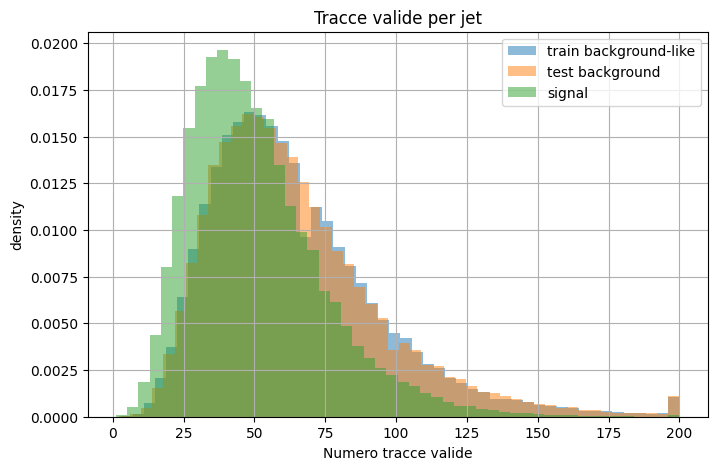

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(mask_train.sum(axis=1), bins=50, density=True, alpha=0.5, label="train background-like")
plt.hist(mask_bg.sum(axis=1), bins=50, density=True, alpha=0.5, label="test background")
plt.hist(mask_sig.sum(axis=1), bins=50, density=True, alpha=0.5, label="signal")
plt.xlabel("Numero tracce valide")
plt.ylabel("density")
plt.title("Tracce valide per jet")
plt.legend()
plt.grid(True)
plt.show()

## 6. Dataset PyTorch

In [6]:
class JetTrackSetDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(X_jets).float()
        self.X_tracks = torch.from_numpy(X_tracks).float()
        self.mask = torch.from_numpy(mask).bool()

    def __len__(self):
        return self.X_jets.shape[0]

    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]

full_dataset = JetTrackSetDataset(X_jets_train, X_tracks_train, mask_train)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 512

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Batch size:", batch_size)

Train: 80000
Validation: 20000
Batch size: 512


## 7. Transformer Set Autoencoder

In [7]:
class TransformerSetAutoencoder(nn.Module):
    def __init__(self, n_track_features, n_jet_features, d_model=96, n_heads=4, n_layers=3, dim_feedforward=256, latent_dim=96, dropout=0.05):
        super().__init__()
        self.n_track_features = n_track_features
        self.n_jet_features = n_jet_features
        self.d_model = d_model
        self.latent_dim = latent_dim

        self.track_embed = nn.Sequential(
            nn.Linear(n_track_features, d_model),
            nn.LayerNorm(d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.SiLU(),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        pooled_dim = 2 * d_model

        self.jet_encoder = nn.Sequential(
            nn.Linear(pooled_dim + n_jet_features, 256),
            nn.LayerNorm(256),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(256, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.SiLU(),
        )

        self.jet_decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.SiLU(),
            nn.Linear(128, n_jet_features),
        )

        self.track_decoder = nn.Sequential(
            nn.Linear(d_model + latent_dim, 256),
            nn.LayerNorm(256),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Linear(128, n_track_features),
        )

    def masked_pool(self, h, mask):
        mask_f = mask.unsqueeze(-1).float()
        denom = mask_f.sum(dim=1).clamp(min=1.0)
        mean_pool = (h * mask_f).sum(dim=1) / denom

        h_for_max = h.masked_fill(~mask.unsqueeze(-1), -1e9)
        max_pool = h_for_max.max(dim=1).values
        max_pool = torch.where(torch.isfinite(max_pool), max_pool, torch.zeros_like(max_pool))
        return torch.cat([mean_pool, max_pool], dim=1)

    def forward(self, x_jets, x_tracks, mask):
        padding_mask = ~mask
        h = self.track_embed(x_tracks)
        h = h * mask.unsqueeze(-1)
        h = self.transformer(h, src_key_padding_mask=padding_mask)
        h = h * mask.unsqueeze(-1)

        pooled = self.masked_pool(h, mask)
        z = self.jet_encoder(torch.cat([pooled, x_jets], dim=1))
        reco_jets = self.jet_decoder(z)

        B, N, _ = h.shape
        z_nodes = z.unsqueeze(1).expand(B, N, z.shape[-1])
        reco_tracks = self.track_decoder(torch.cat([h, z_nodes], dim=-1))
        reco_tracks = reco_tracks * mask.unsqueeze(-1)
        return reco_jets, reco_tracks, z

## 8. Loss

In [8]:
def masked_track_mse(reco_tracks, x_tracks, mask):
    mask_f = mask.unsqueeze(-1).float()
    diff2 = (reco_tracks - x_tracks) ** 2
    diff2 = diff2 * mask_f
    denom = mask_f.sum() * x_tracks.shape[-1]
    denom = denom.clamp(min=1.0)
    return diff2.sum() / denom


def jet_mse(reco_jets, x_jets):
    return torch.mean((reco_jets - x_jets) ** 2)


def transformer_ae_loss(reco_jets, reco_tracks, x_jets, x_tracks, mask, jet_weight=1.0, track_weight=1.0):
    loss_jets = jet_mse(reco_jets, x_jets)
    loss_tracks = masked_track_mse(reco_tracks, x_tracks, mask)
    loss = jet_weight * loss_jets + track_weight * loss_tracks
    return loss, loss_jets, loss_tracks

## 9. Crea modello

In [9]:
n_track_features = X_tracks_train.shape[-1]
n_jet_features = X_jets_train.shape[-1]

d_model = 96
n_heads = 4
n_layers = 3
dim_feedforward = 256
latent_dim = 96
dropout = 0.05

jet_weight = 1.0
track_weight = 1.0

model = TransformerSetAutoencoder(
    n_track_features=n_track_features,
    n_jet_features=n_jet_features,
    d_model=d_model,
    n_heads=n_heads,
    n_layers=n_layers,
    dim_feedforward=dim_feedforward,
    latent_dim=latent_dim,
    dropout=dropout,
).to(device)

learning_rate = 3e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

print(model)
print("n_track_features:", n_track_features)
print("n_jet_features:", n_jet_features)
print("d_model:", d_model)
print("latent_dim:", latent_dim)
print("learning_rate:", learning_rate)

C:\Users\andre\AppData\Local\Temp\ipykernel_20556\3707936428.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


TransformerSetAutoencoder(
  (track_embed): Sequential(
    (0): Linear(in_features=12, out_features=96, bias=True)
    (1): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): SiLU()
    (3): Linear(in_features=96, out_features=96, bias=True)
    (4): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    (5): SiLU()
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=256, bias=True)
        (dropout): Dropout(p=0.05, inplace=False)
        (linear2): Linear(in_features=256, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.05

## 10. Training

In [10]:
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    total_jet_loss = 0.0
    total_track_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for x_jets, x_tracks, mask in loader:
            x_jets = x_jets.to(device, non_blocking=True)
            x_tracks = x_tracks.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)
            reco_jets, reco_tracks, _ = model(x_jets, x_tracks, mask)
            loss, loss_jets, loss_tracks = transformer_ae_loss(reco_jets, reco_tracks, x_jets, x_tracks, mask, jet_weight, track_weight)
            bs = x_jets.shape[0]
            total_loss += loss.item() * bs
            total_jet_loss += loss_jets.item() * bs
            total_track_loss += loss_tracks.item() * bs
            total_items += bs

    return total_loss / total_items, total_jet_loss / total_items, total_track_loss / total_items

n_epochs = 80
early_stopping_patience = 12

train_losses, train_jet_losses, train_track_losses = [], [], []
val_losses, val_jet_losses, val_track_losses = [], [], []
lr_history = []

best_val_loss = np.inf
best_epoch = -1
best_state_dict = None
epochs_without_improvement = 0

for epoch in range(n_epochs):
    model.train()
    total_loss = total_jet_loss = total_track_loss = 0.0
    total_items = 0

    for x_jets, x_tracks, mask in train_loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        optimizer.zero_grad()
        reco_jets, reco_tracks, _ = model(x_jets, x_tracks, mask)
        loss, loss_jets, loss_tracks = transformer_ae_loss(reco_jets, reco_tracks, x_jets, x_tracks, mask, jet_weight, track_weight)

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        bs = x_jets.shape[0]
        total_loss += loss.item() * bs
        total_jet_loss += loss_jets.item() * bs
        total_track_loss += loss_tracks.item() * bs
        total_items += bs

    train_loss = total_loss / total_items
    train_jet_loss = total_jet_loss / total_items
    train_track_loss = total_track_loss / total_items
    val_loss, val_jet_loss, val_track_loss = evaluate_model(model, val_loader)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss); train_jet_losses.append(train_jet_loss); train_track_losses.append(train_track_loss)
    val_losses.append(val_loss); val_jet_losses.append(val_jet_loss); val_track_losses.append(val_track_loss)
    lr_history.append(current_lr)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch+1:03d}/{n_epochs} | "
        f"train={train_loss:.6f} jet={train_jet_loss:.6f} track={train_track_loss:.6f} | "
        f"val={val_loss:.6f} jet={val_jet_loss:.6f} track={val_track_loss:.6f} | "
        f"best={best_val_loss:.6f} @ {best_epoch} | lr={current_lr:.2e}"
    )

    if epochs_without_improvement >= early_stopping_patience:
        print("Early stopping.")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"Loaded best model from epoch {best_epoch} with val loss={best_val_loss:.6f}")

Epoch 001/80 | train=0.541606 jet=0.352513 track=0.189092 | val=0.064628 jet=0.048723 track=0.015905 | best=0.064628 @ 1 | lr=3.00e-04
Epoch 002/80 | train=0.052471 jet=0.033033 track=0.019438 | val=0.022027 jet=0.015843 track=0.006183 | best=0.022027 @ 2 | lr=3.00e-04
Epoch 003/80 | train=0.025868 jet=0.013389 track=0.012479 | val=0.010253 jet=0.006842 track=0.003411 | best=0.010253 @ 3 | lr=3.00e-04
Epoch 004/80 | train=0.017854 jet=0.008420 track=0.009435 | val=0.007404 jet=0.005095 track=0.002309 | best=0.007404 @ 4 | lr=3.00e-04
Epoch 005/80 | train=0.014289 jet=0.006515 track=0.007775 | val=0.005392 jet=0.003601 track=0.001791 | best=0.005392 @ 5 | lr=3.00e-04
Epoch 006/80 | train=0.012196 jet=0.005465 track=0.006731 | val=0.004437 jet=0.003068 track=0.001369 | best=0.004437 @ 6 | lr=3.00e-04
Epoch 007/80 | train=0.010704 jet=0.004723 track=0.005981 | val=0.004100 jet=0.002871 track=0.001229 | best=0.004100 @ 7 | lr=3.00e-04
Epoch 008/80 | train=0.009673 jet=0.004249 track=0.0054

## 11. Plot training

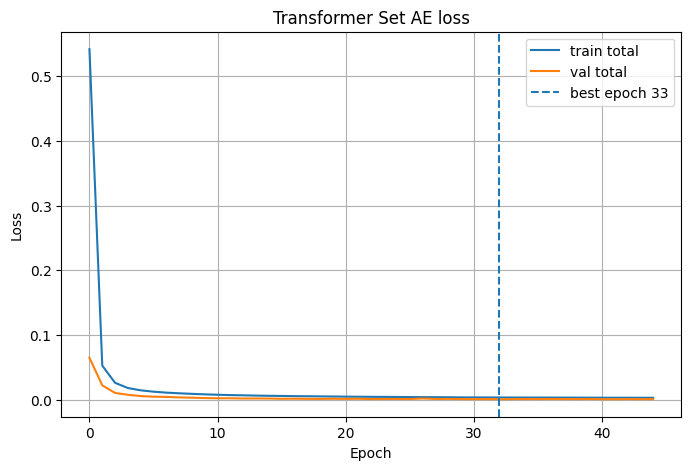

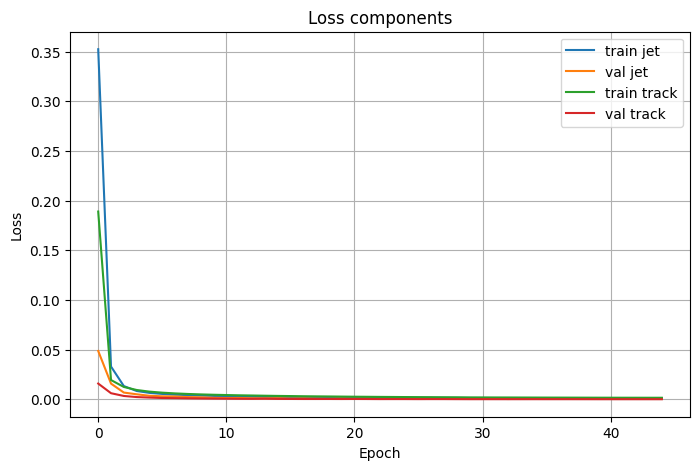

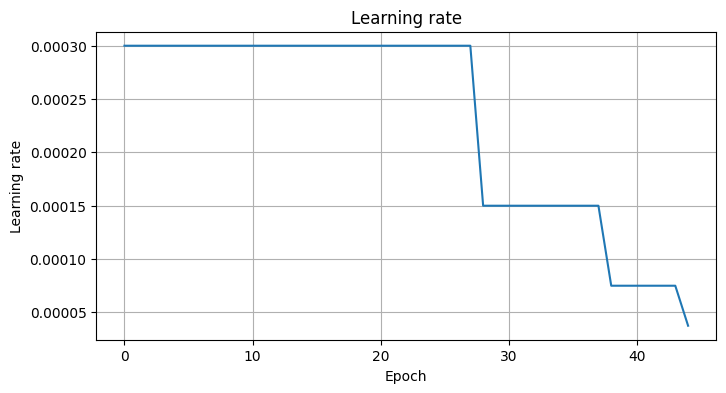

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train total")
plt.plot(val_losses, label="val total")
plt.axvline(best_epoch - 1, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Set AE loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_jet_losses, label="train jet")
plt.plot(val_jet_losses, label="val jet")
plt.plot(train_track_losses, label="train track")
plt.plot(val_track_losses, label="val track")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss components")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate")
plt.grid(True)
plt.show()

## 12. Anomaly scores

In [12]:
class JetTrackEvalDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(X_jets).float()
        self.X_tracks = torch.from_numpy(X_tracks).float()
        self.mask = torch.from_numpy(mask).bool()

    def __len__(self):
        return self.X_jets.shape[0]

    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]


def compute_transformer_scores(model, X_jets, X_tracks, mask, batch_size=1024):
    dataset = JetTrackEvalDataset(X_jets, X_tracks, mask)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

    model.eval()
    total_scores, jet_scores, track_scores, embeddings = [], [], [], []

    with torch.no_grad():
        for x_jets, x_tracks, mask_batch in loader:
            x_jets = x_jets.to(device, non_blocking=True)
            x_tracks = x_tracks.to(device, non_blocking=True)
            mask_batch = mask_batch.to(device, non_blocking=True)

            reco_jets, reco_tracks, z = model(x_jets, x_tracks, mask_batch)
            jet_error = ((reco_jets - x_jets) ** 2).mean(dim=1)

            diff2_tracks = (reco_tracks - x_tracks) ** 2
            diff2_tracks = diff2_tracks * mask_batch.unsqueeze(-1)
            track_error_sum = diff2_tracks.sum(dim=(1, 2))
            track_denom = (mask_batch.sum(dim=1) * x_tracks.shape[-1]).clamp(min=1)
            track_error = track_error_sum / track_denom

            total_score = jet_weight * jet_error + track_weight * track_error
            total_scores.append(total_score.cpu().numpy())
            jet_scores.append(jet_error.cpu().numpy())
            track_scores.append(track_error.cpu().numpy())
            embeddings.append(z.cpu().numpy())

    return np.concatenate(total_scores), np.concatenate(jet_scores), np.concatenate(track_scores), np.concatenate(embeddings, axis=0)

scores_train, scores_train_jets, scores_train_tracks, Z_train = compute_transformer_scores(model, X_jets_train, X_tracks_train, mask_train)
scores_bg, scores_bg_jets, scores_bg_tracks, Z_bg = compute_transformer_scores(model, X_jets_bg, X_tracks_bg, mask_bg)
scores_sig, scores_sig_jets, scores_sig_tracks, Z_sig = compute_transformer_scores(model, X_jets_sig, X_tracks_sig, mask_sig)

def print_score_summary(name, scores):
    print("", name)
    print("mean:", scores.mean())
    print("std:", scores.std())
    print("median:", np.median(scores))
    print("quantiles:", np.percentile(scores, [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]))

print_score_summary("train total score", scores_train)
print_score_summary("background total score", scores_bg)
print_score_summary("signal total score", scores_sig)
print_score_summary("background jet score", scores_bg_jets)
print_score_summary("signal jet score", scores_sig_jets)
print_score_summary("background track score", scores_bg_tracks)
print_score_summary("signal track score", scores_sig_tracks)

 train total score
mean: 0.00051466434
std: 0.00232033
median: 0.00032889802
quantiles: [6.33573509e-05 1.34079754e-04 1.69550080e-04 2.44334988e-04
 3.28898022e-04 4.92265797e-04 1.27608283e-03 3.04384461e-03
 1.01547289e-02 4.53439265e-01]
 background total score
mean: 0.00056015054
std: 0.0038419235
median: 0.00033090738
quantiles: [7.02805846e-05 1.34071838e-04 1.70257299e-04 2.44752911e-04
 3.30907380e-04 4.99041489e-04 1.34584118e-03 3.28725129e-03
 1.56394981e-02 7.00009465e-01]
 signal total score
mean: 0.0016250944
std: 0.0028808264
median: 0.0007252698
quantiles: [1.20869699e-04 2.17401385e-04 2.83236898e-04 4.52240856e-04
 7.25269783e-04 1.62911043e-03 6.03208439e-03 1.16546359e-02
 2.42211114e-02 1.76673651e-01]
 background jet score
mean: 0.00037836152
std: 0.0028204683
median: 0.00017568062
quantiles: [9.23938933e-06 3.61789795e-05 5.61574239e-05 1.07033369e-04
 1.75680609e-04 3.22478583e-04 1.13332882e-03 2.97075125e-03
 1.35763075e-02 6.94283187e-01]
 signal jet score
m

## 13. ROC/AUC e distribuzioni

Transformer total score             AUC=0.8012 AUC_inv=0.1988 best=0.8012


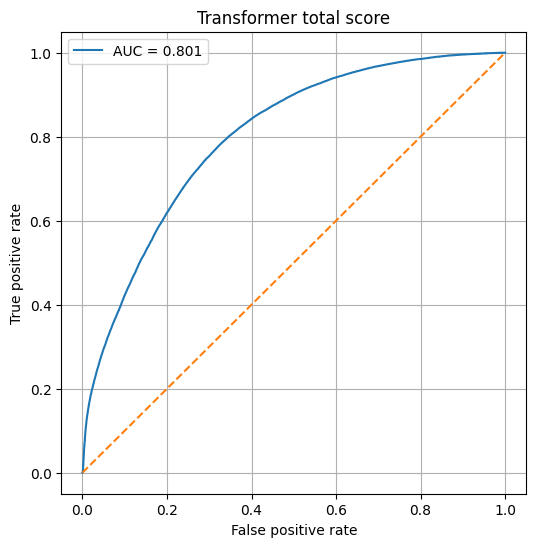

Transformer jet score               AUC=0.8002 AUC_inv=0.1998 best=0.8002


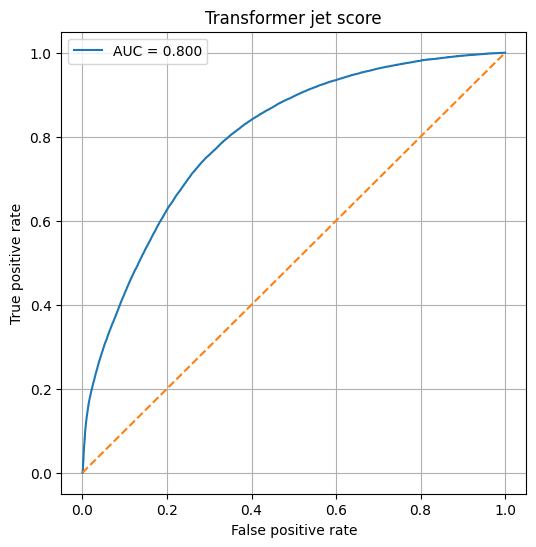

Transformer track score             AUC=0.6408 AUC_inv=0.3592 best=0.6408


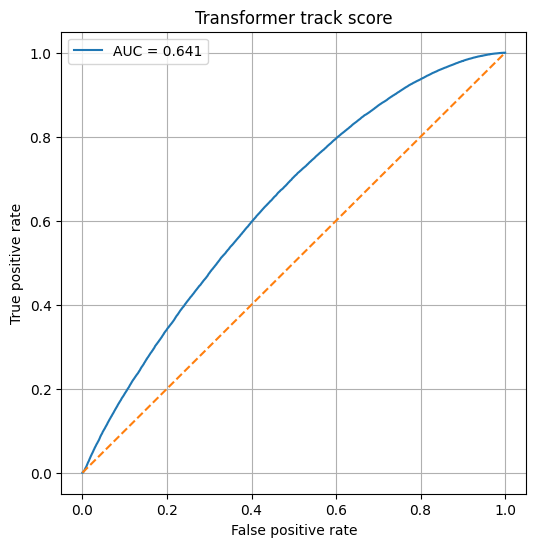

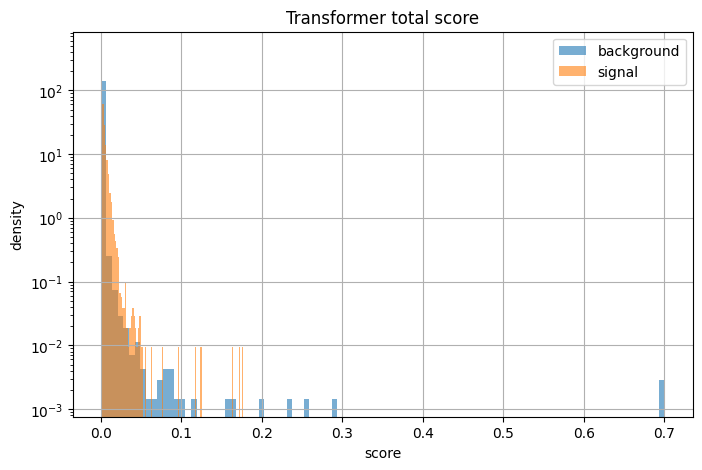

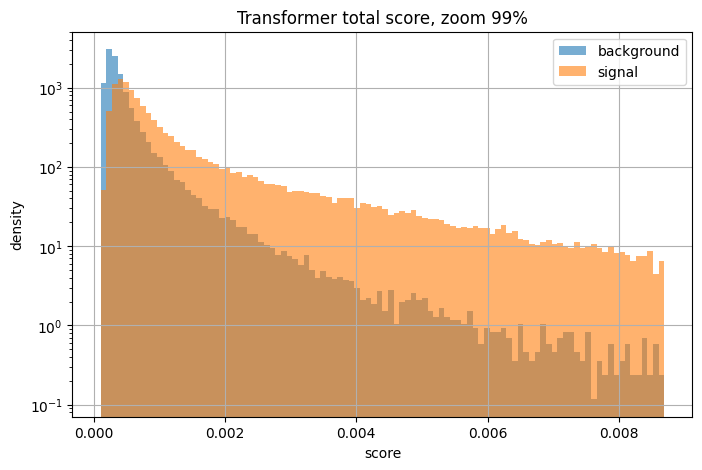

In [13]:
def evaluate_binary_scores(bg_scores, sig_scores, title, make_plot=True):
    y_true = np.concatenate([np.zeros_like(bg_scores), np.ones_like(sig_scores)])
    y_score = np.concatenate([bg_scores, sig_scores])

    auc = roc_auc_score(y_true, y_score)
    auc_inv = roc_auc_score(y_true, -y_score)
    best_auc = max(auc, auc_inv)
    print(f"{title:35s} AUC={auc:.4f} AUC_inv={auc_inv:.4f} best={best_auc:.4f}")

    if make_plot:
        if auc_inv > auc:
            plot_score = -y_score
            label = f"AUC inverted = {auc_inv:.3f}"
        else:
            plot_score = y_score
            label = f"AUC = {auc:.3f}"

        fpr, tpr, _ = roc_curve(y_true, plot_score)
        plt.figure(figsize=(6, 6))
        plt.plot(fpr, tpr, label=label)
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False positive rate")
        plt.ylabel("True positive rate")
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.show()

    return auc, auc_inv, best_auc


def plot_score_distribution(bg_scores, sig_scores, title, zoom_percentile=None):
    plt.figure(figsize=(8, 5))
    if zoom_percentile is not None:
        all_scores = np.concatenate([bg_scores, sig_scores])
        lo = np.percentile(all_scores, 0.1)
        hi = np.percentile(all_scores, zoom_percentile)
        plot_range = (lo, hi)
    else:
        plot_range = None

    plt.hist(bg_scores, bins=100, range=plot_range, density=True, alpha=0.6, label="background")
    plt.hist(sig_scores, bins=100, range=plot_range, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel("score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

auc_total, auc_total_inv, best_auc_total = evaluate_binary_scores(scores_bg, scores_sig, "Transformer total score", make_plot=True)
auc_jets, auc_jets_inv, best_auc_jets = evaluate_binary_scores(scores_bg_jets, scores_sig_jets, "Transformer jet score", make_plot=True)
auc_tracks, auc_tracks_inv, best_auc_tracks = evaluate_binary_scores(scores_bg_tracks, scores_sig_tracks, "Transformer track score", make_plot=True)

plot_score_distribution(scores_bg, scores_sig, "Transformer total score")
plot_score_distribution(scores_bg, scores_sig, "Transformer total score, zoom 99%", zoom_percentile=99)

## 14. Train vs test background

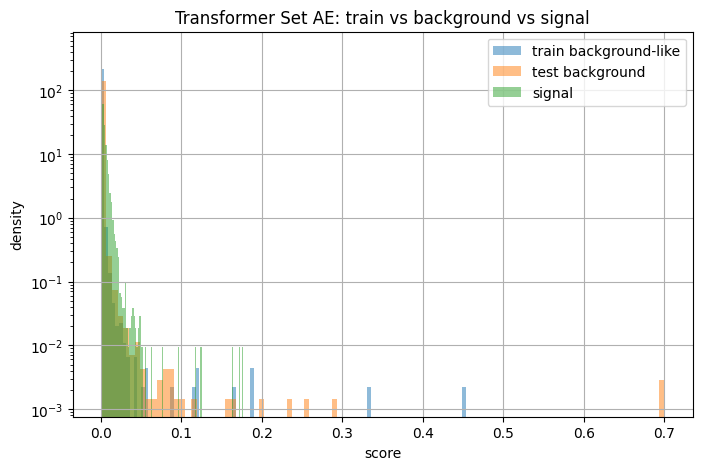

Train vs test background AUC: 0.5036355547
Train vs test background AUC inverted: 0.4963644453
Best train-vs-test-background AUC: 0.5036355547


In [14]:
def compare_train_bg_sig(train_scores, bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))
    plt.hist(train_scores, bins=100, density=True, alpha=0.5, label="train background-like")
    plt.hist(bg_scores, bins=100, density=True, alpha=0.5, label="test background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.5, label="signal")
    plt.yscale("log")
    plt.xlabel("score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    y = np.concatenate([np.zeros_like(train_scores), np.ones_like(bg_scores)])
    s = np.concatenate([train_scores, bg_scores])
    auc_tb = roc_auc_score(y, s)
    auc_tb_inv = roc_auc_score(y, -s)
    best_auc_tb = max(auc_tb, auc_tb_inv)
    print("Train vs test background AUC:", auc_tb)
    print("Train vs test background AUC inverted:", auc_tb_inv)
    print("Best train-vs-test-background AUC:", best_auc_tb)
    return auc_tb, auc_tb_inv, best_auc_tb

auc_train_bg, auc_train_bg_inv, best_auc_train_bg = compare_train_bg_sig(scores_train, scores_bg, scores_sig, "Transformer Set AE: train vs background vs signal")

## 15. Diagnostica supervisionata su latent embedding

In [15]:
print("Z_train:", Z_train.shape)
print("Z_bg:", Z_bg.shape)
print("Z_sig:", Z_sig.shape)

X_clf = np.concatenate([Z_bg, Z_sig], axis=0)
y_clf = np.concatenate([np.zeros(Z_bg.shape[0], dtype=np.int64), np.ones(Z_sig.shape[0], dtype=np.int64)])

X_tr, X_te, y_tr, y_te = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf)
clf = LogisticRegression(max_iter=3000)
clf.fit(X_tr, y_tr)
proba = clf.predict_proba(X_te)[:, 1]
auc_latent_logreg = roc_auc_score(y_te, proba)
print("Supervised logistic regression AUC on Transformer latent embeddings:", auc_latent_logreg)

Z_train: (100000, 96)
Z_bg: (100000, 96)
Z_sig: (59643, 96)
Supervised logistic regression AUC on Transformer latent embeddings: 0.9886507721827904


## 16. Track-only aggregate baseline diagnostica

In [16]:
def aggregate_track_features(X_tracks, mask):
    features = []
    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    features.append(n_valid)

    for i in range(X_tracks.shape[-1]):
        vals = X_tracks[:, :, i]
        valid_vals = np.where(mask, vals, np.nan)
        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)
        features.extend([mean, std, median, q90, maxv])

    out = np.concatenate(features, axis=1)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out.astype(np.float32)

A_bg_tracks = aggregate_track_features(X_tracks_bg, mask_bg)
A_sig_tracks = aggregate_track_features(X_tracks_sig, mask_sig)
mean_tracks = A_bg_tracks.mean(axis=0, keepdims=True)
std_tracks = np.maximum(A_bg_tracks.std(axis=0, keepdims=True), 1e-8)
A_bg_tracks_norm = (A_bg_tracks - mean_tracks) / std_tracks
A_sig_tracks_norm = (A_sig_tracks - mean_tracks) / std_tracks

X_clf_tracks = np.concatenate([A_bg_tracks_norm, A_sig_tracks_norm], axis=0)
y_clf_tracks = np.concatenate([np.zeros(A_bg_tracks_norm.shape[0], dtype=np.int64), np.ones(A_sig_tracks_norm.shape[0], dtype=np.int64)])

X_tr, X_te, y_tr, y_te = train_test_split(X_clf_tracks, y_clf_tracks, test_size=0.3, random_state=42, stratify=y_clf_tracks)
clf_tracks = LogisticRegression(max_iter=3000)
clf_tracks.fit(X_tr, y_tr)
proba_tracks = clf_tracks.predict_proba(X_te)[:, 1]
auc_track_agg_logreg = roc_auc_score(y_te, proba_tracks)
print("Supervised logistic regression AUC on aggregate track features:", auc_track_agg_logreg)

Supervised logistic regression AUC on aggregate track features: 0.9895473872464091


## 17. Test di invarianza all ordine

In [17]:
def permutation_invariance_check(model, X_jets, X_tracks, mask, n_samples=512):
    model.eval()
    Xj = torch.from_numpy(X_jets[:n_samples]).float().to(device)
    Xt = torch.from_numpy(X_tracks[:n_samples]).float().to(device)
    M = torch.from_numpy(mask[:n_samples]).bool().to(device)
    B, N, F = Xt.shape

    perm = torch.stack([torch.randperm(N, device=device) for _ in range(B)], dim=0)
    perm_exp = perm.unsqueeze(-1).expand(B, N, F)
    Xt_perm = torch.gather(Xt, dim=1, index=perm_exp)
    M_perm = torch.gather(M, dim=1, index=perm)

    with torch.no_grad():
        reco_j, _, z = model(Xj, Xt, M)
        reco_j_p, _, z_p = model(Xj, Xt_perm, M_perm)
        dz = torch.mean(torch.abs(z - z_p)).item()
        dj = torch.mean(torch.abs(reco_j - reco_j_p)).item()

    print("Mean abs difference latent after track permutation:", dz)
    print("Mean abs difference reco_jets after track permutation:", dj)

permutation_invariance_check(model, X_jets_bg, X_tracks_bg, mask_bg, n_samples=512)

Mean abs difference latent after track permutation: 5.067736807973233e-08
Mean abs difference reco_jets after track permutation: 9.71439106933758e-08


## 18. Salvataggio

In [18]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "dataset_name": DATASET_NAME,
        "jet_feature_names": jet_feature_names,
        "track_feature_names": track_feature_names,
        "n_track_features": n_track_features,
        "n_jet_features": n_jet_features,
        "d_model": d_model,
        "n_heads": n_heads,
        "n_layers": n_layers,
        "dim_feedforward": dim_feedforward,
        "latent_dim": latent_dim,
        "dropout": dropout,
        "jet_weight": jet_weight,
        "track_weight": track_weight,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_jet_losses": train_jet_losses,
        "val_jet_losses": val_jet_losses,
        "train_track_losses": train_track_losses,
        "val_track_losses": val_track_losses,
        "lr_history": lr_history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "auc_total": auc_total,
        "auc_total_inv": auc_total_inv,
        "best_auc_total": best_auc_total,
        "auc_jets": auc_jets,
        "auc_jets_inv": auc_jets_inv,
        "best_auc_jets": best_auc_jets,
        "auc_tracks": auc_tracks,
        "auc_tracks_inv": auc_tracks_inv,
        "best_auc_tracks": best_auc_tracks,
        "auc_train_bg": auc_train_bg,
        "auc_train_bg_inv": auc_train_bg_inv,
        "best_auc_train_bg": best_auc_train_bg,
        "auc_latent_logreg": auc_latent_logreg,
        "auc_track_agg_logreg": auc_track_agg_logreg,
    },
    OUTPUT_DIR / "transformer_set_autoencoder.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "transformer_set_scores.npz",
    scores_train=scores_train,
    scores_bg=scores_bg,
    scores_sig=scores_sig,
    scores_train_jets=scores_train_jets,
    scores_bg_jets=scores_bg_jets,
    scores_sig_jets=scores_sig_jets,
    scores_train_tracks=scores_train_tracks,
    scores_bg_tracks=scores_bg_tracks,
    scores_sig_tracks=scores_sig_tracks,
    Z_train=Z_train,
    Z_bg=Z_bg,
    Z_sig=Z_sig,
    jet_feature_names=np.array(jet_feature_names, dtype=object),
    track_feature_names=np.array(track_feature_names, dtype=object),
    auc_total=np.array(auc_total, dtype=np.float32),
    auc_total_inv=np.array(auc_total_inv, dtype=np.float32),
    best_auc_total=np.array(best_auc_total, dtype=np.float32),
    auc_jets=np.array(auc_jets, dtype=np.float32),
    auc_tracks=np.array(auc_tracks, dtype=np.float32),
    best_auc_jets=np.array(best_auc_jets, dtype=np.float32),
    best_auc_tracks=np.array(best_auc_tracks, dtype=np.float32),
    auc_train_bg=np.array(auc_train_bg, dtype=np.float32),
    best_auc_train_bg=np.array(best_auc_train_bg, dtype=np.float32),
    auc_latent_logreg=np.array(auc_latent_logreg, dtype=np.float32),
    auc_track_agg_logreg=np.array(auc_track_agg_logreg, dtype=np.float32),
)

config = {
    "dataset_name": DATASET_NAME,
    "processed_files": {k: str(v) for k, v in processed_files.items()},
    "EVAL_ONLY_TRUE_DISPLACED_SIGNAL": EVAL_ONLY_TRUE_DISPLACED_SIGNAL,
    "jet_features": jet_feature_names,
    "track_features": track_feature_names,
    "d_model": d_model,
    "n_heads": n_heads,
    "n_layers": n_layers,
    "dim_feedforward": dim_feedforward,
    "latent_dim": latent_dim,
    "dropout": dropout,
    "jet_weight": jet_weight,
    "track_weight": track_weight,
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
    "best_auc_total": float(best_auc_total),
    "best_auc_jets": float(best_auc_jets),
    "best_auc_tracks": float(best_auc_tracks),
    "best_auc_train_bg": float(best_auc_train_bg),
    "auc_latent_logreg": float(auc_latent_logreg),
    "auc_track_agg_logreg": float(auc_track_agg_logreg),
}

with open(OUTPUT_DIR / "transformer_set_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
print(OUTPUT_DIR / "transformer_set_autoencoder.pt")
print(OUTPUT_DIR / "transformer_set_scores.npz")
print(OUTPUT_DIR / "transformer_set_config.json")

Saved:
outputs_transformer_set\transformer_set_autoencoder.pt
outputs_transformer_set\transformer_set_scores.npz
outputs_transformer_set\transformer_set_config.json


## Interpretazione

Cose da guardare:

1. **Total score AUC**: risultato anomaly detection principale.
2. **Jet score vs track score**: se il track score e' piu' forte, il modello usa davvero la struttura delle tracce.
3. **Train vs test background AUC**: deve essere vicino a 0.5. Se e' alto, il modello distingue background di train e test.
4. **Latent logistic regression AUC**: diagnostica supervisionata, non risultato anomaly detection.
5. **Permutation invariance check**: le differenze devono essere molto piccole. Se sono grandi, qualcosa introduce dipendenza dall'ordine.